# Pandas Data Cleaning & Analysis: Flight Delays – My BA Version
Forked from JP Morgan Chase python-training repo  
Customized by S33mi ( February 2026)  
Goal: Master pandas for real data wrangling, cleaning, aggregation, and visualization – skills used daily in business analysis (e.g., operational reporting, risk metrics).
Dataset: Airline routes + airports (OpenFlights style) + delays (focus on cleaning & insights).

**Original repo uses local OpenFlights data files.**  https://openflights.org/

**Here we also load data directly from GitHub raw URLs avaiable in data section.**

In [1]:
#New cell added by S33mi
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')

import pandas as pd
import numpy as np
import plotly.express as px   # Interactive plots (pre-installed in Colab)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Example #2 - Working with files on local file system
(PS: I'm using colabs so if you want to know how to access and online data please jump to this section **Accessing Online Repository Data Content**)

Let's make sure our data files are there. The `os` library will be very helpful.

In [2]:
from os import listdir
from os.path import join

listdir('.')

['.config', 'sample_data']

In [ ]:
listdir('../data') #this will work on your local system to list contant on data folder

We will rely on `pandas`'s built in `read_csv` function.

In [ ]:
import pandas as pd
pd.read_csv?

What other "read" functions does `pandas` have?

In [ ]:
import re
regex = re.compile(r'read')
list(filter(regex.match, dir(pd)))

Let's focus on `read_csv` for now, and investigate some data from [openflights.org](openflights.org)

In [ ]:
routes = pd.read_csv(join('..', 'data', 'routes.csv'))
airports = pd.read_csv(join('..', 'data', 'airports.csv'))

In [ ]:
routes.head()

In [ ]:
routes.info()

Looks like there's some missing data points...can we visualize what that looks like?

In [ ]:
import missingno as msno

`missingno` is a library that wraps together handy data utilities to get a visual summary of data completeness. We will only scratch the surface of this library.

In [ ]:
%matplotlib inline
msno.matrix(routes)

This gives a quick display to visually check out your data. The sparkline on the right shows the completeness of the data. Let's check out airports.

In [ ]:
airports.info()

In [ ]:
msno.matrix(airports)

Cool! Overall the csvs look pretty clean, with relatively complete data. We've got ~68000 airline routes and ~7000 airports around the world. Let's see if this list is real by trying to find everyone's favorite airport - LaGuardia (LGA).

In [ ]:
airports[airports['IATA'] == 'LGA']

Awesome. How about finding some other things like the highest airport in the world, highest airport in the country that comes last alphabetically, and the highest airport in Australia.

In [ ]:
highest = airports.sort_values('altitude', ascending=False).iloc[0]
highestInLastAlpha = airports.sort_values(['country', 'altitude'], ascending=[False, False]).iloc[0]
highestInAustralia = airports[airports['country'] == 'Australia'].sort_values('altitude', ascending=False).iloc[0]

In [ ]:
print(f'Highest airport: \n{highest}\n\n')
print(f'Highest airport in the country that comes last alphabetically: \n{highestInLastAlpha}\n\n')
print(f'Highest airport in Australia: \n{highestInAustralia}\n\n')

Let's do some more practical things with this data like finding the 10 busiest routes in the world.

In [ ]:
busiest = routes.groupby(['source', 'dest']).count()['airline_id'].nlargest(10)
busiest

We can merge in the names of the airports.

In [ ]:
busiest = pd.DataFrame(busiest).reset_index()
busiest.head()

In [ ]:
for sd in ['source', 'dest']:
    busiest = busiest.merge(airports[['IATA', 'name']].set_index('IATA'), how='left', left_on=sd, right_on='IATA')

busiest

#End of examples in orignal notebook 3_flights.ipynb https://github.com/jpmorganchase/python-training/blob/main/notebooks/3_flights.ipynb

#Accessing Online Repository Data Content
Try to use python script for notebooks
# 3 – Working with Data – Flights

(Adapted from JPMC Python Training – now using online data from S33mi fork)

Original repo uses local OpenFlights data files.  
Here we load them directly from GitHub raw URLs.

In [25]:
# Cell 1: Imports & setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from math import radians, sin, cos, sqrt, atan2

%matplotlib inline
plt.style.use('ggplot')

In [5]:
import requests

url = "https://api.github.com/repos/S33mi/jpmc-python-training-notes/contents/data"
response = requests.get(url)

if response.status_code == 200:
    files = [item['name'] for item in response.json()]
    print("Contents of /dataset:")
    for f in files:
        print(f"  - {f}")
else:
    print("Failed to fetch:", response.status_code)

Contents of /dataset:
  - airports.csv
  - data_norm.csv
  - data_raw.csv
  - routes.csv
  - yield_curve.csv


#Import load and read data from CSV

In [32]:
import pandas as pd

# Example 1: Read airports.csv (most common for training/notes)
url = "https://raw.githubusercontent.com/S33mi/jpmc-python-training-notes/main/data/airports.csv"
df_air = pd.read_csv(url)

# Quick inspection
print("Shape:", df_air.shape)
print("\nFirst 5 rows:")
display(df_air.head())          # Nice table view in Colab
print("\nColumns:", df_air.columns.tolist())
print("\nData types:\n", df_air.dtypes)

Shape: (7698, 14)

First 5 rows:


,id,name,city,country,IATA,ICAO,lat,long,altitude,timezone,dst,tzinfo,type,source
0,1,Goroka Airport,Goroka,Papua New Guinea,GKA,AYGA,-6.08,145.39,5282,10,U,Pacific/Port_Moresby,airport,OurAirports
1,2,Madang Airport,Madang,Papua New Guinea,MAG,AYMD,-5.21,145.79,20,10,U,Pacific/Port_Moresby,airport,OurAirports
2,3,Mount Hagen Kagamuga Airport,Mount Hagen,Papua New Guinea,HGU,AYMH,-5.83,144.30,5388,10,U,Pacific/Port_Moresby,airport,OurAirports
3,4,Nadzab Airport,Nadzab,Papua New Guinea,LAE,AYNZ,-6.57,146.73,239,10,U,Pacific/Port_Moresby,airport,OurAirports
4,5,Port Moresby Jacksons International Airport,Port Moresby,Papua New Guinea,POM,AYPY,-9.44,147.22,146,10,U,Pacific/Port_Moresby,airport,OurAirports



Columns: ['id', 'name', 'city', 'country', 'IATA', 'ICAO', 'lat', 'long', 'altitude', 'timezone', 'dst', 'tzinfo', 'type', 'source']

Data types:
 id            int64
name         object
city         object
country      object
IATA         object
ICAO         object
lat         float64
long        float64
altitude      int64
timezone     object
dst          object
tzinfo       object
type         object
source       object
dtype: object


In [33]:
# Example 2: yield_curve.csv (financial data)
url = "https://raw.githubusercontent.com/S33mi/jpmc-python-training-notes/main/data/yield_curve.csv"
dff = pd.read_csv(url)
display(dff.head(10))   # Show more rows if needed

,x,y,z[0],z[1],z[2],z[3],z[4],z[5],z[6],z[7],z[8],z[9],z[10]
0,1-month,1990-01-02,NaN,7.83,7.89,7.81,7.87,7.90,7.87,7.98,7.94,NaN,8.00
1,3-month,1990-01-03,NaN,7.89,7.94,7.85,7.94,7.96,7.92,8.04,7.99,NaN,8.04
2,6-month,1990-01-04,NaN,7.84,7.90,7.82,7.92,7.93,7.91,8.02,7.98,NaN,8.04
3,1-year,1990-01-05,NaN,7.79,7.85,7.79,7.90,7.94,7.92,8.03,7.99,NaN,8.06
4,2-year,1990-01-08,NaN,7.79,7.88,7.81,7.90,7.95,7.92,8.05,8.02,NaN,8.09
5,3-year,1990-01-09,NaN,7.80,7.82,7.78,7.91,7.94,7.92,8.05,8.02,NaN,8.10
6,5-year,1990-01-10,NaN,7.75,7.78,7.77,7.91,7.95,7.92,8.00,8.03,NaN,8.11
7,7-year,1990-01-11,NaN,7.80,7.80,7.77,7.91,7.95,7.94,8.01,8.04,NaN,8.11
8,10-year,1990-01-12,NaN,7.74,7.81,7.76,7.93,7.98,7.99,8.07,8.10,NaN,8.17
9,20-year,1990-01-16,NaN,7.89,7.99,7.92,8.10,8.13,8.11,8.18,8.20,NaN,8.25


In [34]:
# Example 3: routes.csv (larger file – may take a few seconds)
url = "https://raw.githubusercontent.com/S33mi/jpmc-python-training-notes/main/data/routes.csv"
dfr = pd.read_csv(url, low_memory=False)  # Helps with big files
print(dfr.info())                         # Memory usage & types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67663 entries, 0 to 67662
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   airline     67663 non-null  object
 1   airline_id  67663 non-null  object
 2   source      67663 non-null  object
 3   source_id   67663 non-null  object
 4   dest        67663 non-null  object
 5   dest_id     67663 non-null  object
 6   codeshare   14597 non-null  object
 7   stops       67663 non-null  int64 
 8   equipment   67645 non-null  object
dtypes: int64(1), object(8)
memory usage: 4.6+ MB
None


#All-in-One: Load All CSVs into a Dictionary
If you want to explore everything at once:

In [9]:
import pandas as pd

base_url = "https://raw.githubusercontent.com/S33mi/jpmc-python-training-notes/main/data/"
files = [
    "airports.csv",
    "data_norm.csv",
    "data_raw.csv",
    "routes.csv",
    "yield_curve.csv"
]

data = {}
for file in files:
    try:
        data[file] = pd.read_csv(base_url + file)
        print(f"Loaded {file}: {data[file].shape}")
    except Exception as e:
        print(f"Error loading {file}: {e}")

# Now access like: data['airports.csv'].head()

Loaded airports.csv: (7698, 14)
Loaded data_norm.csv: (125, 2)
Loaded data_raw.csv: (125, 15)
Loaded routes.csv: (67663, 9)
Loaded yield_curve.csv: (6307, 13)


#Analyze Missing Values

Read CSV and convert missing values to NaN.

This will show us that IATA  and tzinfo  are the most missing data in Airport file.

While in the route file codeshare has only 22% available data information.

In [16]:
# Airports
airports_url = "https://raw.githubusercontent.com/S33mi/jpmc-python-training-notes/main/data/airports.csv"
#airports = pd.read_csv(airports_url, na_values=['\\N', '']) # convert \N and blanks to NaN

airports = pd.read_csv(
    airports_url,
    header=None,                  # OpenFlights format usually has no header
    names=[
        'Airport ID', 'Name', 'City', 'Country', 'IATA', 'ICAO',
        'Latitude', 'Longitude', 'Altitude', 'Timezone', 'DST',
        'Tz database time zone', 'Type', 'Source'
    ],
    na_values=['\\N'],            # OpenFlights uses \N for missing
    index_col=0                   # Often index by Airport ID
)

print("Airports shape:", airports.shape)
airports.head(3)



Airports shape: (7699, 13)


,Name,City,Country,IATA,ICAO,Latitude,Longitude,Altitude,Timezone,DST,Tz database time zone,Type,Source
Airport ID,,,,,,,,,,,,,
id,name,city,country,IATA,ICAO,lat,long,altitude,timezone,dst,tzinfo,type,source
1,Goroka Airport,Goroka,Papua New Guinea,GKA,AYGA,-6.081689834590001,145.391998291,5282,10,U,Pacific/Port_Moresby,airport,OurAirports
2,Madang Airport,Madang,Papua New Guinea,MAG,AYMD,-5.20707988739,145.789001465,20,10,U,Pacific/Port_Moresby,airport,OurAirports


In [17]:
# Routes  Cell 3: Load routes data
routes_url = "https://raw.githubusercontent.com/S33mi/jpmc-python-training-notes/main/data/routes.csv"
#routes = pd.read_csv(routes_url, na_values=['\\N', '']) # convert \N and blanks to NaN
#
ROUTES_URL = "https://raw.githubusercontent.com/S33mi/jpmc-python-training-notes/main/data/routes.csv"

routes = pd.read_csv(
    ROUTES_URL,
    header=None,
    names=[
        'Airline', 'Airline ID', 'Source airport', 'Source airport ID',
        'Destination airport', 'Destination airport ID', 'Codeshare',
        'Stops', 'Equipment'
    ],
    na_values=['\\N']
)

print("Routes shape:", routes.shape)
routes.head(3)

Routes shape: (67664, 9)


/tmp/ipython-input-177/460181707.py:7: DtypeWarning: Columns (1,3,5,7) have mixed types. Specify dtype option on import or set low_memory=False.
  routes = pd.read_csv(


,Airline,Airline ID,Source airport,Source airport ID,Destination airport,Destination airport ID,Codeshare,Stops,Equipment
0,airline,airline_id,source,source_id,dest,dest_id,codeshare,stops,equipment
1,2B,410,AER,2965,KZN,2990,NaN,0,CR2
2,2B,410,ASF,2966,KZN,2990,NaN,0,CR2


In [18]:
#Missing data in Airport
print("Airports shape:", airports.shape)
print("\nMissing values per column:")
missing_air = airports.isnull().sum()
print(missing_air[missing_air > 0])  # Only columns with misses

print("\nMissing percentages:")
print((missing_air[missing_air > 0] / len(airports) * 100).round(2))

Airports shape: (7699, 13)

Missing values per column:
City                       49
IATA                     1626
ICAO                        1
Timezone                  353
DST                       353
Tz database time zone    1021
dtype: int64

Missing percentages:
City                     0.64
IATA                    21.12
ICAO                     0.01
Timezone                 4.59
DST                      4.59
Tz database time zone   13.26
dtype: float64


In [19]:
#Missing data in routes
print("Routes shape:", routes.shape)
print("\nMissing values per column:")
missing_routes = routes.isnull().sum()
print(missing_routes[missing_routes > 0])

print("\nMissing percentages:")
print((missing_routes[missing_routes > 0] / len(routes) * 100).round(2))

Routes shape: (67664, 9)

Missing values per column:
Airline ID                  479
Source airport ID           220
Destination airport ID      221
Codeshare                 53066
Equipment                    18
dtype: int64

Missing percentages:
Airline ID                0.71
Source airport ID         0.33
Destination airport ID    0.33
Codeshare                78.43
Equipment                 0.03
dtype: float64


#Visualizing Missing Values

<Axes: >

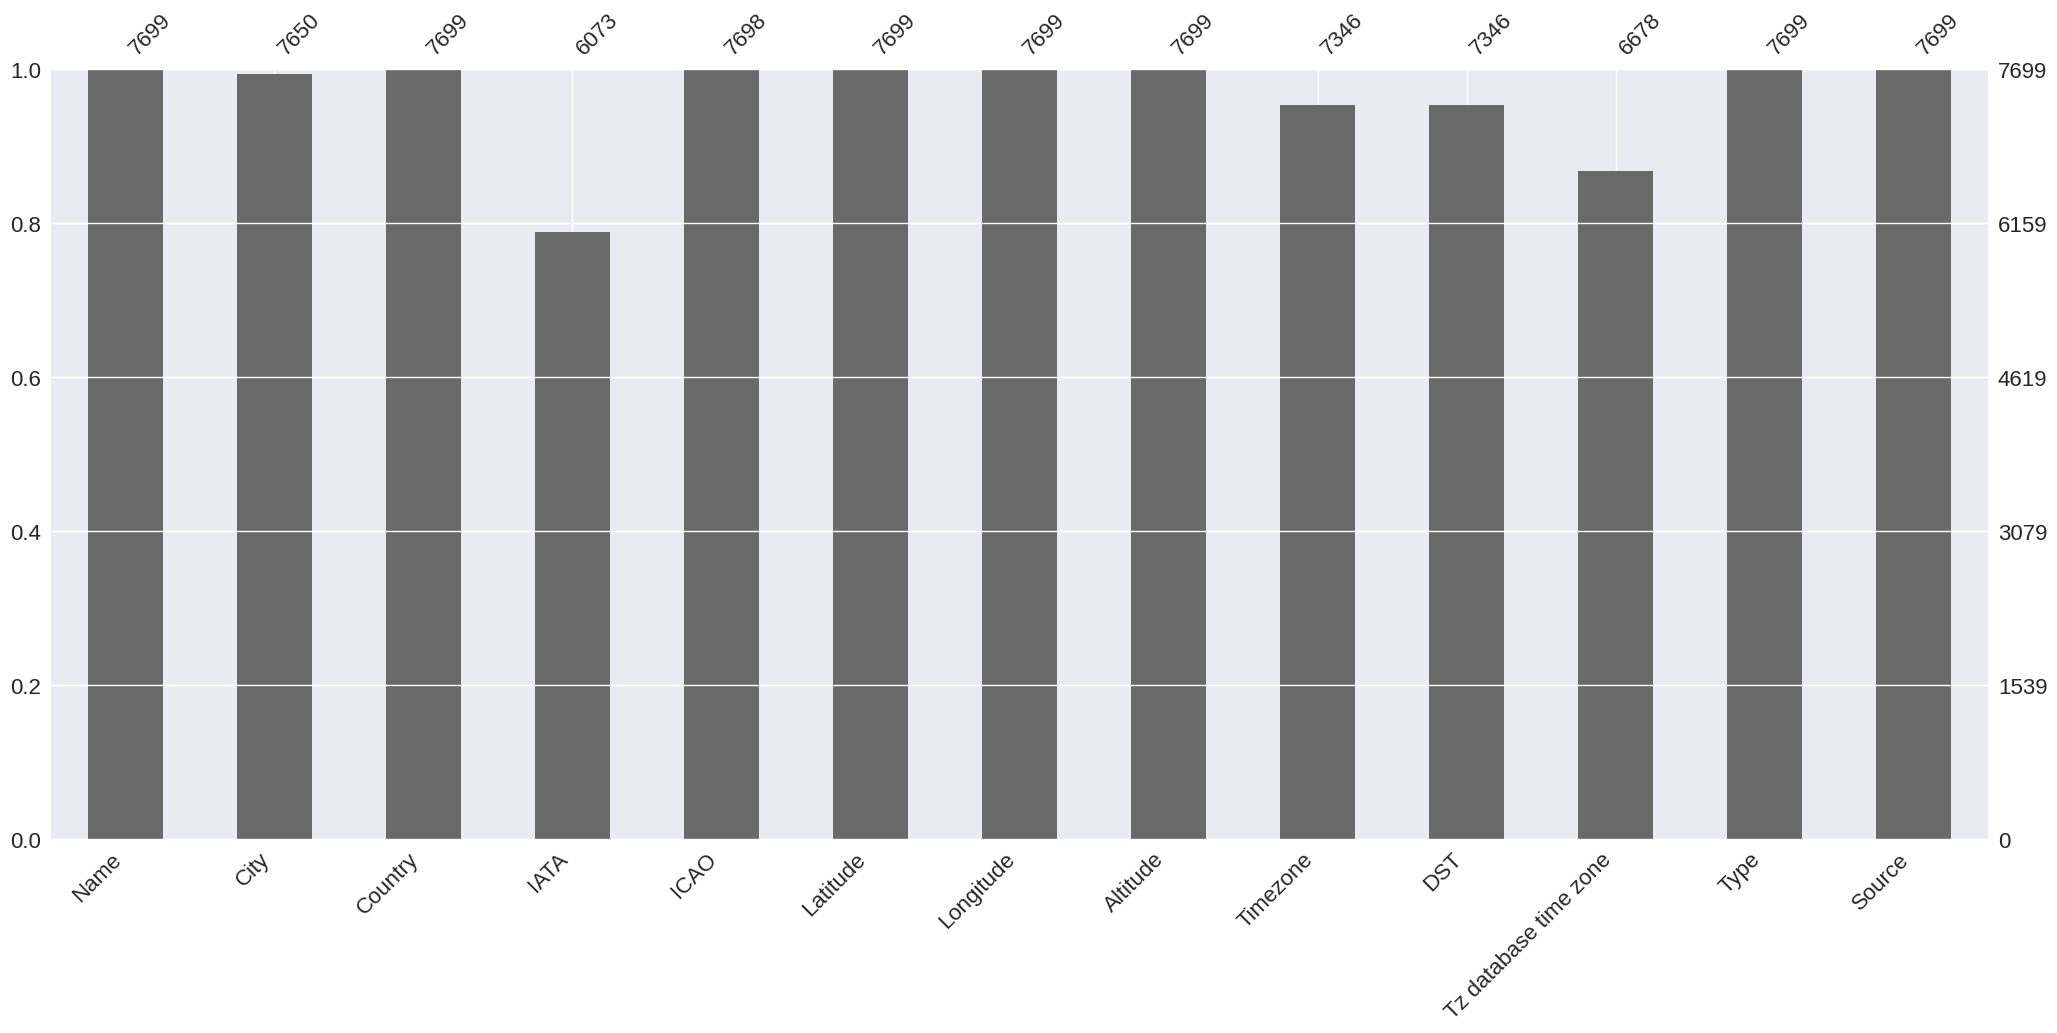

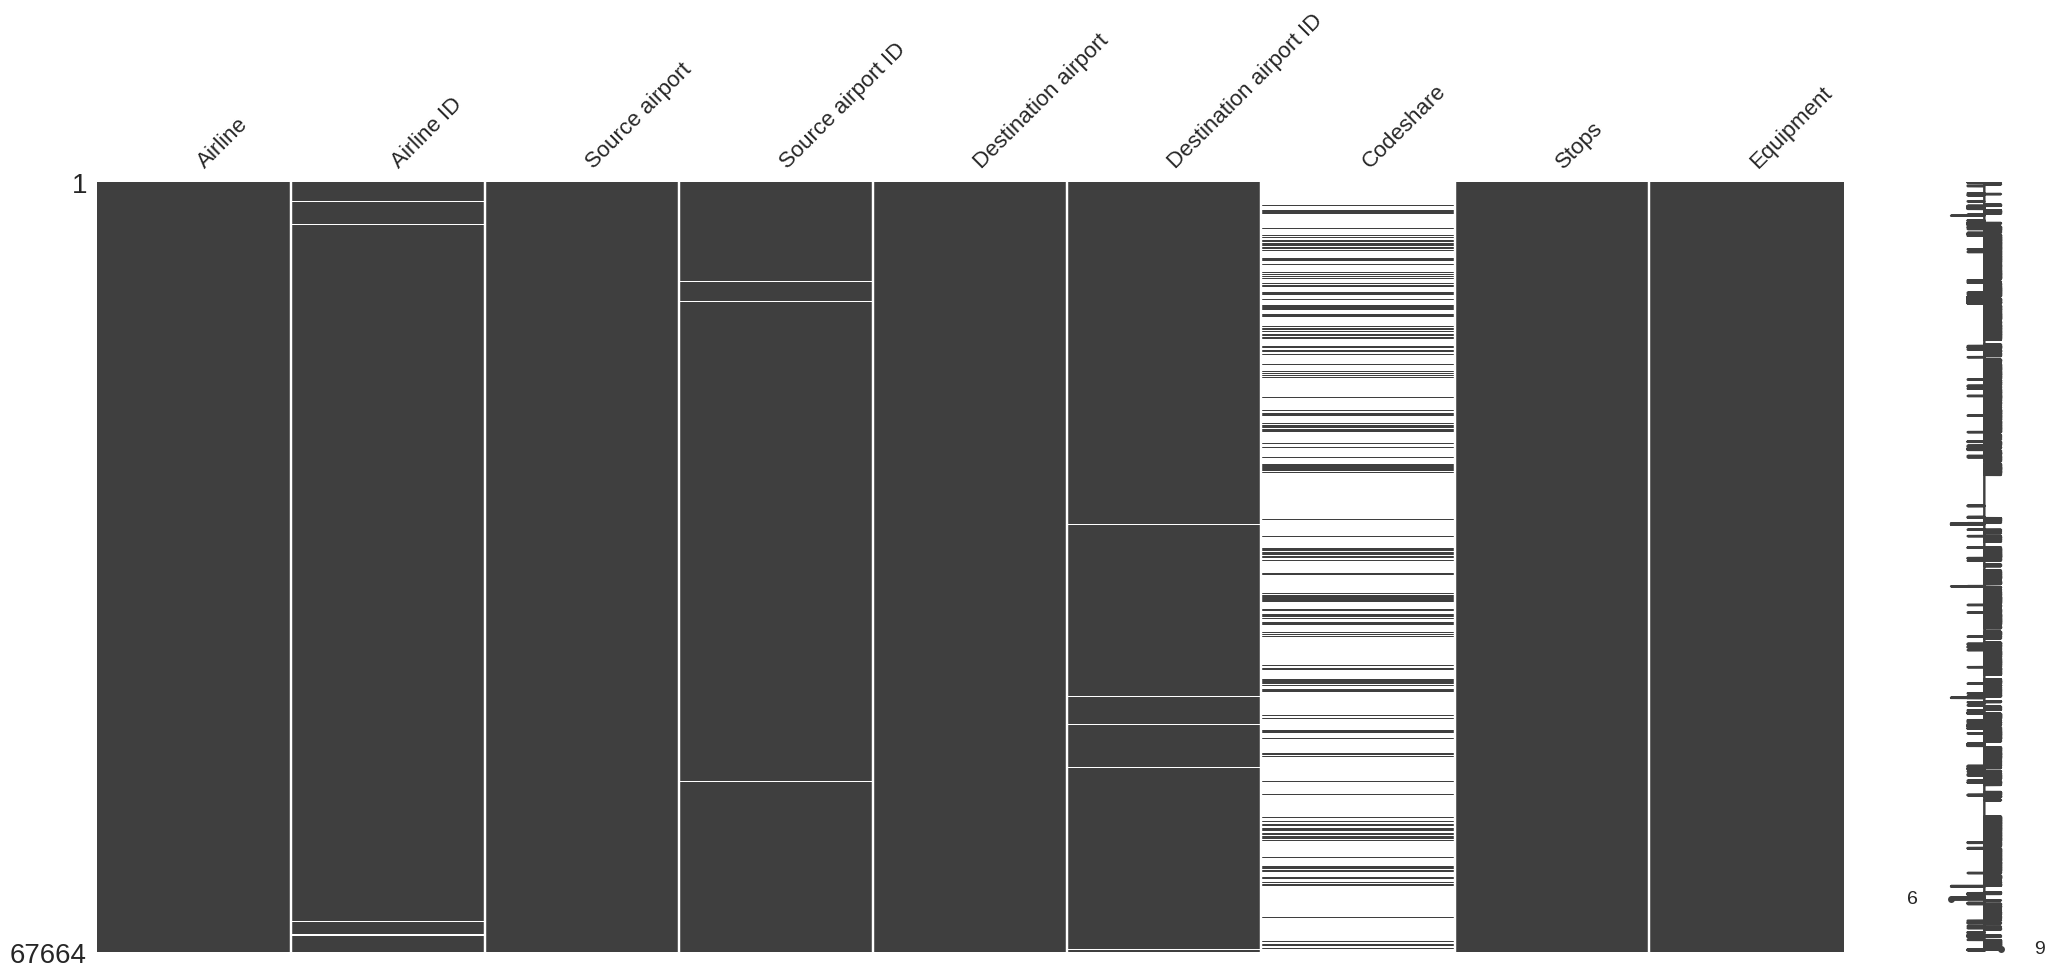

In [20]:
import missingno as msno
msno.bar(airports)   # Bar chart of completeness
msno.matrix(routes)  # Pattern matrix

In [28]:
# Cell 4: Quick cleaning / filtering (common in the notebook)
# Keep only routes with exactly 0 stops (direct flights)
direct_routes = routes[routes['Stops'] == 0].copy()

# Merge source & destination airport info
flights = direct_routes.merge(
    airports[['Name', 'City', 'Country', 'IATA', 'Latitude', 'Longitude']],
    left_on='Source airport',
    right_on='IATA',
    how='left'
).rename(columns={
    'Name': 'Source name', 'City': 'Source city', 'Country': 'Source country',
    'Latitude': 'Source lat', 'Longitude': 'Source lon'
}).merge(
    airports[['Name', 'City', 'Country', 'IATA', 'Latitude', 'Longitude']],
    left_on='Destination airport',
    right_on='IATA',
    how='left',
    suffixes=('', '_dest')
).rename(columns={
    'Name': 'Dest name', 'City': 'Dest city', 'Country': 'Dest country',
    'Latitude': 'Dest lat', 'Longitude': 'Dest lon'
})

for col in ['Source lat', 'Source lon', 'Dest lat', 'Dest lon']:
    flights[col] = pd.to_numeric(flights[col], errors='coerce')

#print("Direct flights with airport info:", flights.shape)
print("Direct flights with airport info:", flights.shape)

Direct flights with airport info: (2128, 21)


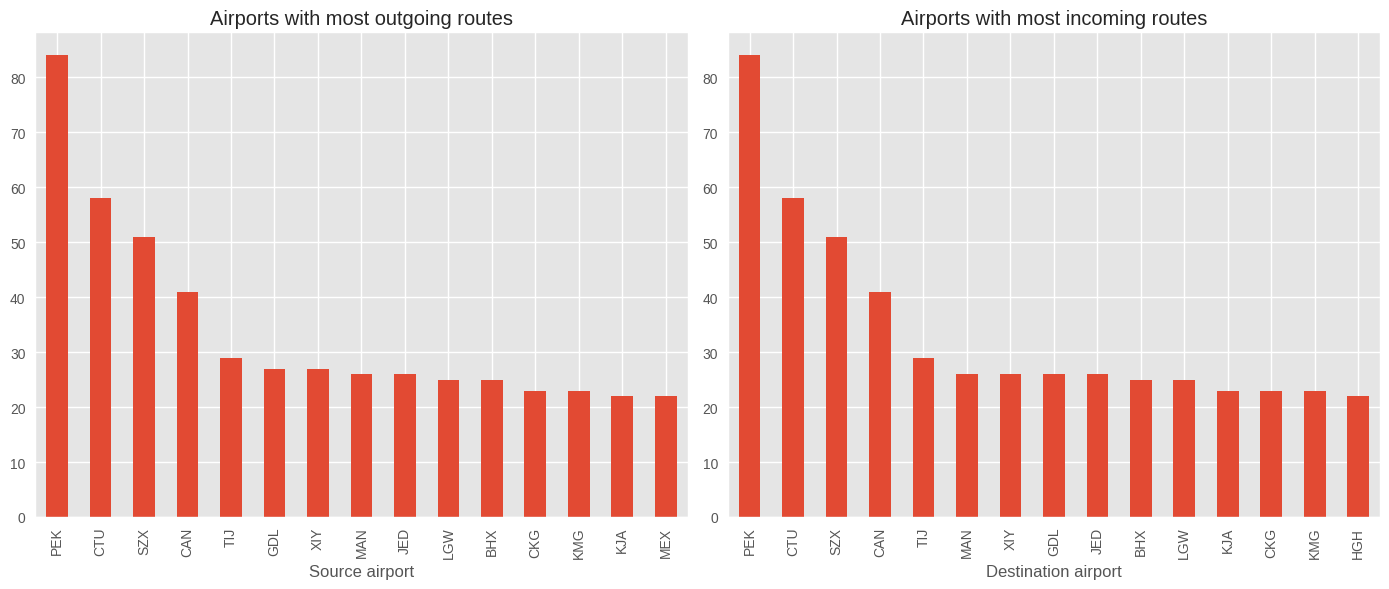

In [29]:
# Cell 5: Example – busiest airports (by number of routes)
outdegree = flights['Source airport'].value_counts().head(15)
indegree  = flights['Destination airport'].value_counts().head(15)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
outdegree.plot(kind='bar', ax=ax[0], title='Airports with most outgoing routes')
indegree.plot(kind='bar', ax=ax[1], title='Airports with most incoming routes')
plt.tight_layout()
plt.show()

Nodes: 488 Edges: 2054


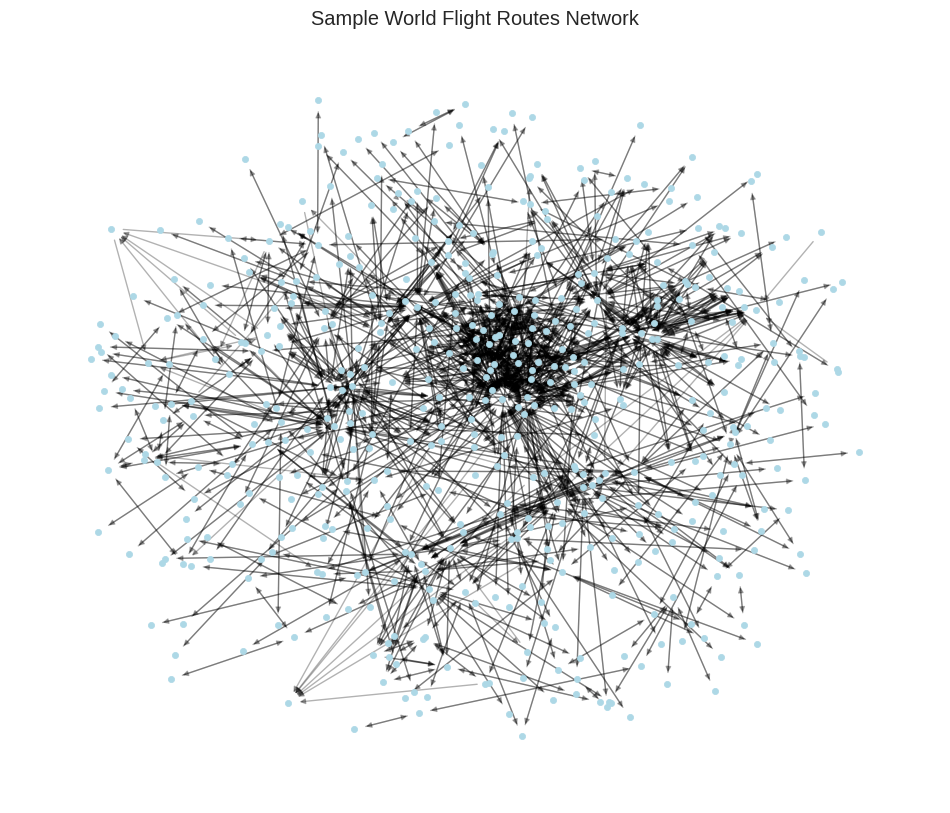

In [30]:
# Cell 6: Build a simple route network graph (common visualization in this notebook)
G = nx.DiGraph()

# Add edges (limit to e.g. 5000 for speed in Colab)
for _, row in flights.head(5000).iterrows():
    if pd.notna(row['Source lat']) and pd.notna(row['Dest lat']):
        G.add_edge(
            row['Source airport'],
            row['Destination airport'],
            weight=1,  # or you can compute distance here
            airline=row['Airline']
        )

print("Nodes:", G.number_of_nodes(), "Edges:", G.number_of_edges())

# Quick drawing (large graphs are slow – subset if needed)
plt.figure(figsize=(12,10))
pos = nx.spring_layout(G, k=0.15, iterations=20)
nx.draw_networkx_nodes(G, pos, node_size=20, node_color='lightblue')
nx.draw_networkx_edges(G, pos, alpha=0.3, arrowsize=8)
plt.title("Sample World Flight Routes Network")
plt.axis('off')
plt.show()

In [31]:
# Optional extra cell: Great-circle distance function (often appears)
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    return R * c

# Example usage
example = flights.iloc[0]
dist = haversine(example['Source lat'], example['Source lon'],
                 example['Dest lat'],   example['Dest lon'])
print(f"Distance {example['Source airport']} → {example['Destination airport']}: {dist:.0f} km")

Distance NUE → AYT: 2114 km


#Analyzing Delays and post load missing Value alanlysis

In [37]:
# delays = pd.read_csv('flights.csv.csv') #https://www.kaggle.com/datasets/patrickzel/flight-delay-and-cancellation-dataset-2019-2023 (~ 614 MB free download)
delays = pd.read_csv('https://raw.githubusercontent.com/YBI-Foundation/Dataset/main/Airline%20Delay.csv') #small public raw CSV
display(delays.head())

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2020,12,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",44.00,3.00,1.63,0.00,0.12,0.00,1.25,0.00,1.00,89.00,56.00,0.00,3.00,0.00,30.00
1,2020,12,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",90.00,1.00,0.96,0.00,0.04,0.00,0.00,0.00,0.00,23.00,22.00,0.00,1.00,0.00,0.00
2,2020,12,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",88.00,8.00,5.75,0.00,1.60,0.00,0.65,0.00,1.00,338.00,265.00,0.00,45.00,0.00,28.00
3,2020,12,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",184.00,9.00,4.17,0.00,1.83,0.00,3.00,0.00,0.00,508.00,192.00,0.00,92.00,0.00,224.00
4,2020,12,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",76.00,11.00,4.78,0.00,5.22,0.00,1.00,1.00,0.00,692.00,398.00,0.00,178.00,0.00,116.00


In [39]:
# Handle missing values strategically
print("Missing values before:\n", delays.isna().sum())

# Fill or drop sensibly (example: assume 'delay_minutes' column)
delays['arr_delay'] = delays['arr_delay'].fillna(0)  # Or use median
#delays = delays.dropna(subset=['flight_date', 'airline'])   # Critical columns

# Convert times to proper datetime (common pain point) in you are using the above mentioned Kaggle data set of US Department of Transportation, Bureau of Transportation Statistics
# delays['flight_date'] = pd.to_datetime(delays['flight_date'], errors='coerce')
#delays['scheduled_dep'] = pd.to_datetime(delays['scheduled_dep_time'], format='%H%M', errors='coerce').dt.time

Missing values before:
 year                   0
month                  0
carrier                0
carrier_name           0
airport                0
airport_name           0
arr_flights            8
arr_del15              8
carrier_ct             8
weather_ct             8
nas_ct                 8
security_ct            8
late_aircraft_ct       8
arr_cancelled          8
arr_diverted           8
arr_delay              0
carrier_delay          8
weather_delay          8
nas_delay              8
security_delay         8
late_aircraft_delay    8
dtype: int64


In [40]:
# Example: United States airports/routes
us_airports = airports[airports['Country'] == 'United States']
print("United States Airports:", len(us_airports))
display(us_airports[['Name', 'City', 'IATA', 'Latitude', 'Longitude']])

United States Airports: 1512


,Name,City,IATA,Latitude,Longitude
Airport ID,,,,,
3411,Barter Island LRRS Airport,Barter Island,BTI,70.1340026855,-143.582000732
3412,Wainwright Air Station,Fort Wainwright,NaN,70.61340332,-159.8600006
3413,Cape Lisburne LRRS Airport,Cape Lisburne,LUR,68.87509918,-166.1100006
3414,Point Lay LRRS Airport,Point Lay,PIZ,69.73290253,-163.0050049
3415,Hilo International Airport,Hilo,ITO,19.721399307250977,-155.04800415039062
...,...,...,...,...,...
13717,Camp Pendleton MCAS (Munn Field) Airport,Oceanside,NaN,33.30130005,-117.3550034
13757,Vidalia Regional Airport,Vidalia,VDI,32.192699432373,-82.371200561523
13758,Granbury Regional Airport,Granbury,NaN,32.44440079,-97.81690216


In [43]:
routes_with_origin = routes.merge(airports[['IATA', 'Country']], left_on='Source airport', right_on='IATA', suffixes=('', '_origin'))

display(routes_with_origin.head())

,Airline,Airline ID,Source airport,Source airport ID,Destination airport,Destination airport ID,Codeshare,Stops,Equipment,IATA,Country
0,2B,410,AER,2965,KZN,2990,NaN,0,CR2,AER,Russia
1,2B,410,ASF,2966,KZN,2990,NaN,0,CR2,ASF,Russia
2,2B,410,ASF,2966,MRV,2962,NaN,0,CR2,ASF,Russia
3,2B,410,CEK,2968,KZN,2990,NaN,0,CR2,CEK,Russia
4,2B,410,CEK,2968,OVB,4078,NaN,0,CR2,CEK,Russia


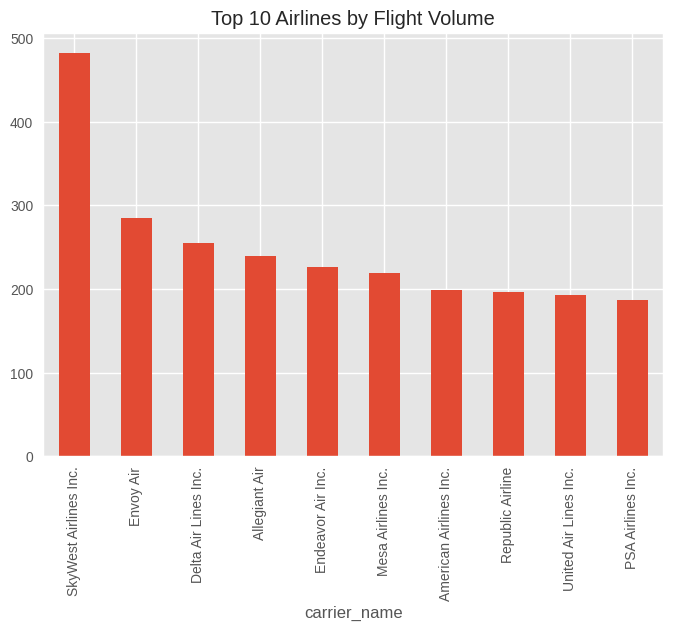

In [45]:
# Busiest airlines by flight count
airline_flights = delays.groupby('carrier_name').size().sort_values(ascending=False).head(10)
airline_flights.plot(kind='bar', title='Top 10 Airlines by Flight Volume')
plt.show()

## Key Takeaways & BA Exercises
- Mastered: Loading, cleaning (NaN/datetime), groupby, pivot_table, filtering, visualization.
- Analogies: Flight delays = project risks; pandas = advanced Excel for large datasets.
- Exercises:
  1. Calculate % of flights delayed by airline.
  2. Merge airports + routes to add country/region info (if not present).
  3. Added USA Flight delays
  4. Uses some data base systems SQL concepts like NaN, Joins/merge and groupby.
Commit to your fork – excellent showcase for JP Morgan BA interviews!

#Want to Explore More on Delays

Use BTS on-time data (monthly CSVs from https://www.transtats.bts.gov/ontime/).

Or Kaggle free dataset:

https://www.kaggle.com/datasets/patrickzel/flight-delay-and-cancellation-dataset-2019-2023

https://www.kaggle.com/datasets/undersc0re/flight-delay-and-causes


Upload to Colab and proceed with original cleaning/missing value analysis.